# Cluster Analysis of MMseqs2 Output

This notebook walks through the workflow of `cluster_first_split.py`, answering key questions about clustering, splitting, and the effect of parameters like `min-seq-id`.
## 1. Import Required Libraries
Import all necessary Python libraries, including pandas, Bio.SeqIO, pathlib, subprocess, re, and json.

In [4]:
# Import Required Libraries
import pandas as pd
import numpy as np
from pathlib import Path
import subprocess
import re
import json
import matplotlib.pyplot as plt
import seaborn as sns
import os

## Analyze Clustering Results
Read the MMseqs2 cluster output files. Count the number of deduplicated sequences and clusters. Display statistics on cluster sizes.

Number of clusters: 3442
Cluster size stats:
count    3442.000000
mean       12.099361
std        41.158584
min         1.000000
25%         1.000000
50%         2.000000
75%         6.000000
max       724.000000
dtype: float64


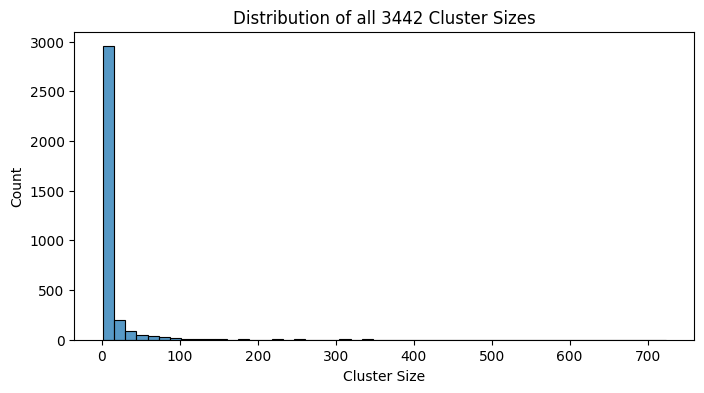

In [ ]:
# Load deduplicated sequences and cluster assignments
output_dir = Path(r"..\data\split\mmseqs2\final_checkpoint41k")

cluster_tsv = output_dir / "output_cluster.tsv"

cluster_df = pd.read_csv(cluster_tsv, sep='\t', header=None, names=["representative", "member"])

max_clusters_all = cluster_df['representative'].nunique()
print(f"Number of clusters: {max_clusters_all}")

# Cluster size statistics
cluster_sizes = cluster_df.groupby("representative").size()
print("Cluster size stats:")
print(cluster_sizes.describe())

plt.figure(figsize=(8,4))
sns.histplot(cluster_sizes, bins=50)
plt.xlabel('Cluster Size')
plt.title(f'Distribution of all {cluster_df['representative'].nunique()} Cluster Sizes')
plt.show()


Number of singleton clusters: 1605
Largest cluster size: 724
Number of clusters with size <= 100: 24110 vs. overall num of seqs: 41646
Number of clusters with size > 100: 17536 vs. overall num of seqs: 41646
Number of clusters with size > 200: 11571 vs. overall num of seqs: 41646
Number of clusters with size > 400: 3956 vs. overall num of seqs: 41646


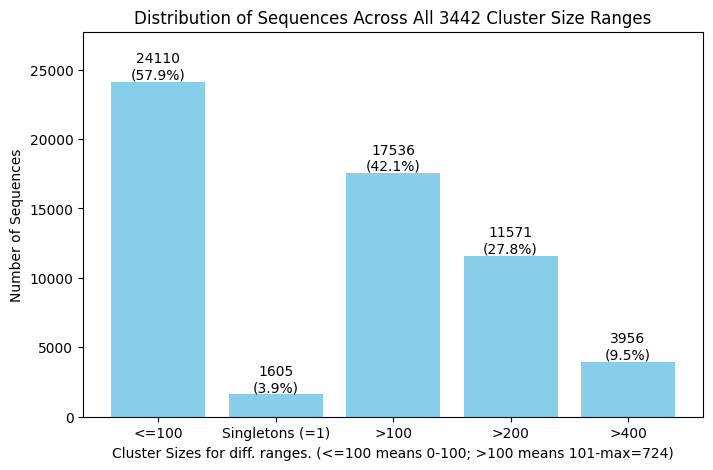

In [62]:
#Number of singleton clusters
num_singletons = (cluster_sizes == 1).sum()
print(f"Number of singleton clusters: {num_singletons}")
print(f"Largest cluster size: {cluster_sizes.max()}")

# print number of sequences in cluster above the x percentile (only ver large clusters)
max_size = 100
filtered_sizes = cluster_sizes[cluster_sizes <= max_size]
print(f"Number of clusters with size <= {max_size}: {sum(filtered_sizes.values)} vs. overall num of seqs: {len(cluster_df)}")


max_size = 100
filtered_sizes = cluster_sizes[cluster_sizes > max_size]
print(f"Number of clusters with size > {max_size}: {sum(filtered_sizes.values)} vs. overall num of seqs: {len(cluster_df)}")

max_size = 200
filtered_sizes = cluster_sizes[cluster_sizes > max_size]
print(f"Number of clusters with size > {max_size}: {sum(filtered_sizes.values)} vs. overall num of seqs: {len(cluster_df)}")

max_size = 400
filtered_sizes = cluster_sizes[cluster_sizes > max_size]
print(f"Number of clusters with size > {max_size}: {sum(filtered_sizes.values)} vs. overall num of seqs: {len(cluster_df)}")


# Data for plotting
thresholds = ['<=100', 'Singletons (=1)', '>100', '>200', '>400']
counts = [24110,1605 , 17536, 11571, 3956]
total_seqs = 41646

# Calculate percentages
percentages = [c / total_seqs * 100 for c in counts]

plt.figure(figsize=(8, 5))
bars = plt.bar(thresholds, counts, color='skyblue')
plt.ylabel('Number of Sequences')
plt.xlabel('Cluster Sizes for diff. ranges. (<=100 means 0-100; >100 means 101-max=724)')
plt.title('Distribution of Sequences Across All 3442 Cluster Size Ranges')

# Annotate bars with counts and percentages
for bar, count, pct in zip(bars, counts, percentages):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{count}\n({pct:.1f}%)',
             ha='center', va='bottom', fontsize=10)

plt.ylim(0, max(counts)*1.15)
plt.show()

[ 1  5  9 13 17 18 28]


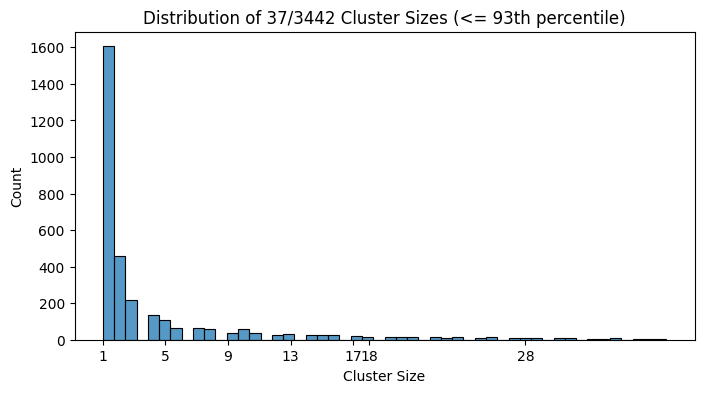

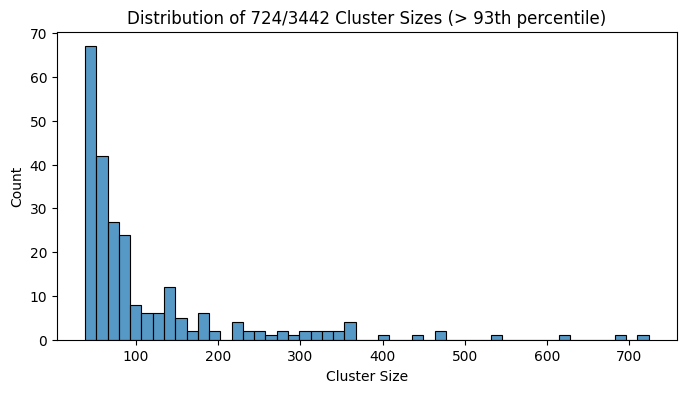

In [71]:
# Plot histogram of cluster sizes up to the nth percentile
n = 93  # Change this value for a different percentile
max_size = np.percentile(cluster_sizes, n)
filtered_sizes = cluster_sizes[cluster_sizes <= max_size]
max_cluster_size = filtered_sizes.max()

plt.figure(figsize=(8,4))
sns.histplot(filtered_sizes, bins=50)
plt.xlabel('Cluster Size')
ticks = np.concatenate([
	np.arange(1, int(max_size // 2), 4),
	np.arange(int(max_size // 2), int(max_size) + 1, 10)
])
print(ticks)
plt.xticks(ticks)  # Adjust x-ticks for better readability
plt.title(f'Distribution of {max_cluster_size}/{max_clusters_all} Cluster Sizes (<= {n}th percentile)')
plt.show()

filtered_sizes = cluster_sizes[cluster_sizes > max_size]
max_cluster_size = filtered_sizes.max()
plt.figure(figsize=(8,4))
sns.histplot(filtered_sizes, bins=50)
plt.xlabel('Cluster Size')
plt.title(f'Distribution of {max_cluster_size}/{max_clusters_all} Cluster Sizes (> {n}th percentile)')
plt.show()


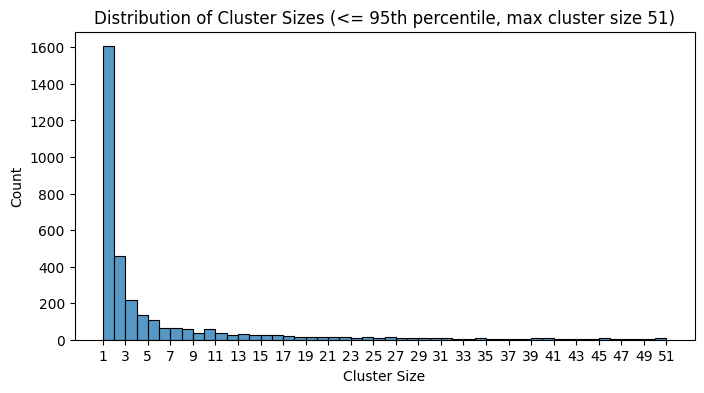

In [34]:
# Plot histogram of cluster sizes up to the nth percentile
n = 95  # Change this value for a different percentile
max_size = np.percentile(cluster_sizes, n)
filtered_sizes = cluster_sizes[cluster_sizes <= max_size]

plt.figure(figsize=(8,4))
sns.histplot(filtered_sizes, bins=50)
plt.xlabel('Cluster Size')
plt.xticks(np.arange(1, max_size + 1, 2))  # Adjust x-ticks for better readability
plt.title(f'Distribution of Cluster Sizes (<= {n}th percentile, max cluster size {int(max_size)})')
plt.show()

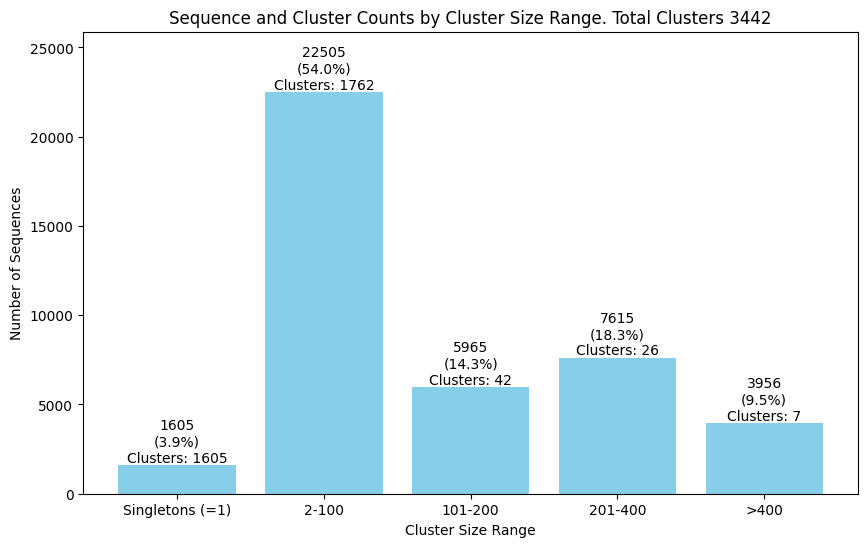

In [73]:
# Dynamically compute counts for each cluster size range
ranges = [(1, 1), (2, 100), (101, 200), (201, 400), (401, cluster_sizes.max())]
labels = ['Singletons (=1)', '2-100', '101-200', '201-400', f'>400']

seq_counts = []
cluster_counts = []
for r in ranges:
    mask = (cluster_sizes >= r[0]) & (cluster_sizes <= r[1])
    seq_counts.append(cluster_sizes[mask].sum())
    cluster_counts.append(mask.sum())

total_seqs = len(cluster_df)
percentages = [c / total_seqs * 100 for c in seq_counts]

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, seq_counts, color='skyblue')
plt.ylabel('Number of Sequences')
plt.xlabel('Cluster Size Range')
plt.title('Sequence and Cluster Counts by Cluster Size Range. Total Clusters 3442')

# Annotate bars with sequence counts, percentages, and number of clusters
for bar, seq_count, pct, clus_count in zip(bars, seq_counts, percentages, cluster_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{seq_count}\n({pct:.1f}%)\nClusters: {clus_count}',
             ha='center', va='bottom', fontsize=10)

plt.ylim(0, max(seq_counts)*1.15)
plt.show()